# Pareto Front Hypervolume Evaluation

## Instance X-n106-k14

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
def extract_pareto_fronts_from_txt(txt_path):
    with open(txt_path, "r", encoding="utf-8") as f:
        text = f.read()

    run_blocks = re.split(r"\r?\n\s*\d+\s+RUN\s*\r?\n", text)

    all_fronts = []

    for block in run_blocks:
        if "Pareto objective values [distance, co2]:" not in block:
            continue

        part = block.split("Pareto objective values [distance, co2]:", 1)[1]

        # keep only the matrix of pareto values
        if "All 20 Pareto solutions:" in part:
            part = part.split("All 20 Pareto solutions:", 1)[0]

        pairs = re.findall(r"\[\s*([0-9.eE+-]+)\s+([0-9.eE+-]+)\s*\]", part)

        front = [(float(a), float(b)) for a, b in pairs]

        if front:
            all_fronts.append(front)

    return all_fronts

def change_fronts(front):
    pts = [(p[0], p[1]) for p in front]
    return sorted(set(pts), key=lambda t: t[0])

def ref_point(list_fronts):
    max_dist = max(p[0] for front in list_fronts for p in front)
    max_co2 = max(p[1] for front in list_fronts for p in front)
    return (max_dist * 1.05, max_co2 * 1.05)

def hypervolume(front, ref_pt):
    sorted_front = sorted(front, key=lambda p: p[0])
    hv = 0.0
    prev_y = ref_pt[1]

    for dist, co2 in sorted_front:
        width = ref_pt[0] - dist
        height = prev_y - co2
        hv += width * height
        prev_y = co2

    return hv

def plot_fronts(weighted_front, median_front, optimal_pt, legend=True):
    xs = [p[0] for p in weighted_front]
    ys = [p[1] for p in weighted_front]

    nsga_x = [p[0] for p in median_front]
    nsga_y = [p[1] for p in median_front]

    plt.scatter(xs, ys, color="green", label="Weighted-sum front")
    plt.scatter(nsga_x, nsga_y, color="blue", label="Median NSGA-II front")
    plt.scatter([optimal_pt[0]], [optimal_pt[1]], color="red", label="Optimal solution")

    plt.xlabel("Total distance")
    plt.ylabel("CO$_2$ emissions")
    plt.title("Distance vs CO$_2$")
    plt.grid(True, alpha=0.3)
    if legend:
        plt.legend()

    plt.show()


In [3]:
all_fronts = extract_pareto_fronts_from_txt("nsga2_eval.txt")
clean_fronts1 = [change_fronts(front) for front in all_fronts[:20]]
rp = ref_point(clean_fronts1)

print(f'Reference point: {rp}')


Reference point: (35178.15, 24602.56387785)


In [4]:
hv_values1 = [hypervolume(front, rp) for front in clean_fronts1]

results_df = pd.DataFrame({
    'Run': np.arange(1, len(clean_fronts1) + 1),
    'Num. of points': [len(front) for front in clean_fronts1],
    'Hypervolume': hv_values1,
})

results_df = results_df.sort_values('Run').reset_index(drop=True)
results_df

results_df = results_df.sort_values('Hypervolume', ascending=True).reset_index(drop=True)
results_df


,Run,Num. of points,Hypervolume
0,3,7,2.103238e+07
1,7,10,2.301604e+07
2,19,23,2.393409e+07
3,13,20,2.400588e+07
4,5,9,2.502604e+07
5,18,20,2.552242e+07
6,15,16,2.669057e+07
7,8,28,2.693128e+07
8,14,10,2.705183e+07
9,12,16,2.723660e+07


In [5]:
sorted_indices = sorted(range(len(hv_values1)), key=lambda i: hv_values1[i])
median_pos = len(hv_values1) // 2
median_idx = sorted_indices[median_pos]

median_hv = hv_values1[median_idx]
median_front = clean_fronts1[median_idx]

print("Median HV:", median_hv)
print("Median front:")
print(median_front)


Median HV: 27764374.67465444
Median front:
[(31141.0, 22354.096419), (31171.0, 22348.732347), (31275.0, 21538.662993), (31278.0, 21537.943155), (31292.0, 21404.4942465), (31293.0, 21173.27787), (31300.0, 21164.789628), (31341.0, 20066.113782), (31526.0, 20046.161898), (31527.0, 19982.2582665), (32293.0, 19794.2967675), (32301.0, 19794.2388255), (32302.0, 19051.621137), (32306.0, 19043.592777), (32324.0, 17136.0211635), (32352.0, 16925.417523), (32402.0, 16641.589158)]


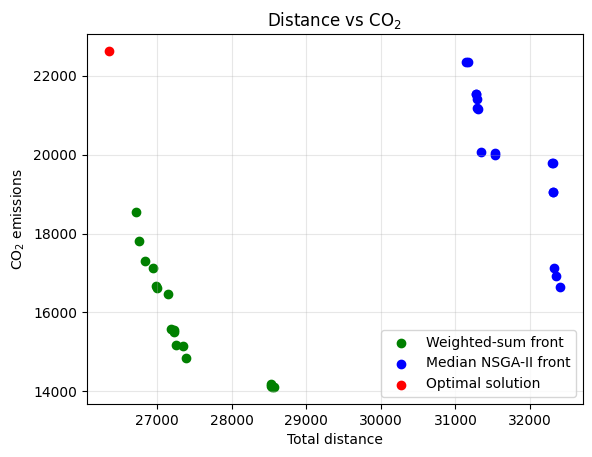

In [6]:
weighted_points = [
(26727, 18544.307215499994),
(26762, 17816.8803795),
(26839, 17293.83311699999),
(26952, 17129.332386),
(26990, 16668.834425999994),
(27003, 16614.413577000014),
(27145, 16458.252448500007),
(27193, 15571.131587999993),
(27223, 15545.139250500004),
(27231, 15492.437347500003),
(27261, 15166.310800499987),
(27351, 15152.802223499999),
(27388, 14849.727718499998),
(28533, 14176.829915999993),
(28535, 14134.011560999992),
(28542, 14115.495437999994),
(28563, 14109.187067999994),
]

optimal_pt = (26362, 22630.28)

plot_fronts(weighted_points, median_front, optimal_pt)


## Instance X-110-k13

In [7]:
clean_fronts2 = [change_fronts(front) for front in all_fronts[20:40]]
rp2 = ref_point(clean_fronts2)

print(f'Reference point: {rp2}')
print(clean_fronts2)

Reference point: (34012.65, 23141.27611215)
[[(31570.0, 17672.113467), (31594.0, 17259.6934035), (31622.0, 17241.427188), (31634.0, 17202.5967825), (31717.0, 16987.0478445), (31727.0, 16755.782922), (31790.0, 16735.0599135)], [(30822.0, 17929.413531), (30846.0, 16748.977608), (30874.0, 16703.165844), (30883.0, 16491.0236085), (30968.0, 16412.6964645), (30996.0, 16365.3411465)], [(30426.0, 22039.310583), (30475.0, 20511.3723435), (30491.0, 19972.0351575), (30494.0, 19286.4377475), (31424.0, 18622.412118), (31467.0, 17403.142266), (31623.0, 16965.5351805), (31662.0, 16913.742732), (31999.0, 16796.45403), (32021.0, 16650.5050485), (32214.0, 16509.36708), (32245.0, 16484.3869005), (32393.0, 16398.352296)], [(21062.0, 12026.19376706), (21187.0, 11417.61642351), (21533.0, 11354.85109928), (21628.0, 11279.28341136), (21726.0, 11191.1662965)], [(21424.0, 13853.00765274), (21427.0, 13675.79472129), (21441.0, 12806.83302407), (21450.0, 12763.97658277), (21545.0, 12718.47899441), (21652.0, 12219.

In [8]:
hv_values2 = [hypervolume(front, rp2) for front in clean_fronts2]
print(hv_values2)

results_df2 = pd.DataFrame({
    'Run': np.arange(1, len(clean_fronts2) + 1),
    'Num. of points': [len(front) for front in clean_fronts2],
    'Hypervolume': hv_values2,
})

results_df2 = results_df2.sort_values('Run').reset_index(drop=True)
results_df2

results_df2 = results_df2.sort_values('Hypervolume', ascending=True).reset_index(drop=True)
results_df2

[15562257.578361932, 21556307.95954968, 20623865.09364791, 154554773.97276187, 149386448.38298124, 168618972.89671907, 158457261.2186069, 159971368.5355101, 143168607.08346522, 138715750.8926183, 124494175.11156191, 176027447.62331644, 150941866.3182793, 175110126.26280245, 172660192.70932484, 179304687.96464485, 135336029.41215414, 146218960.00941125, 156563687.01872566, 161757177.05935782]


,Run,Num. of points,Hypervolume
0,1,7,1.556226e+07
1,3,13,2.062387e+07
2,2,6,2.155631e+07
3,11,7,1.244942e+08
4,17,8,1.353360e+08
5,10,8,1.387158e+08
6,9,4,1.431686e+08
7,18,13,1.462190e+08
8,5,11,1.493864e+08
9,13,12,1.509419e+08


In [9]:
sorted_indices = sorted(range(len(hv_values2)), key=lambda i: hv_values2[i])
median_pos = len(hv_values2) // 2
median_idx = sorted_indices[median_pos]

median_hv = hv_values2[median_idx]
median_front = clean_fronts2[median_idx]

print("Median HV:", median_hv)
print("Median front:")
print(median_front)
print(len(median_front))

Median HV: 154554773.97276187
Median front:
[(21062.0, 12026.19376706), (21187.0, 11417.61642351), (21533.0, 11354.85109928), (21628.0, 11279.28341136), (21726.0, 11191.1662965)]
5


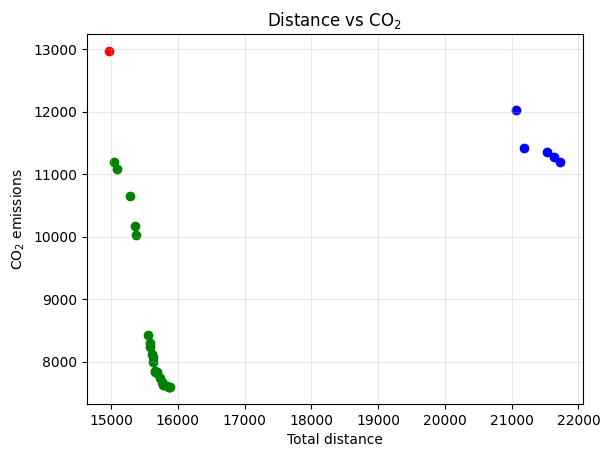

In [10]:
weighted_points = [
(15048, 11192.448128228041, 0.9319397993311037, 0.06806020066889631),
(15094, 11084.983433251155, 0.8687290969899666, 0.13127090301003344),
(15285, 10643.972525500769, 0.8867892976588628, 0.11321070234113713),
(15363, 10166.559971879815, 0.8566889632107023, 0.14331103678929766),
(15369, 10031.901795485355, 0.8596989966555184, 0.1403010033444816),
(15556, 8426.203699506932, 0.8657190635451505, 0.1342809364548495), 
(15575, 8298.421570123262, 0.8506688963210702, 0.14933110367892977), 
(15580, 8243.118601848995, 0.8205685618729097, 0.17943143812709028), 
(15617, 8116.53636064715, 0.7573578595317726, 0.2426421404682274), 
(15624, 8077.11941274268, 0.8145484949832775, 0.18545150501672242), 
(15634, 7995.747700123263, 0.7603678929765887, 0.23963210702341137), 
(15656, 7855.396422018487, 0.7994983277591974, 0.20050167224080268), 
(15661, 7839.5087970416, 0.6971571906354515, 0.3028428093645485), 
(15685, 7836.353777565484, 0.6881270903010034, 0.3118729096989966), 
(15690, 7816.838634637905, 0.7513377926421405, 0.24866220735785954), 
(15733, 7741.513093590135, 0.6399665551839465, 0.3600334448160535), 
(15762, 7679.618033436054, 0.72123745819398, 0.27876254180602006), 
(15772, 7633.481622434514, 0.37508361204013374, 0.6249163879598663), 
(15786, 7633.4661997072435, 0.5797658862876254, 0.42023411371237457), 
(15839, 7614.668621787365, 0.5918060200668896, 0.40819397993311035), 
(15866, 7603.074913312789, 0.10719063545150498, 0.892809364548495), 
(15871, 7599.602302280429, 0.22759197324414715, 0.7724080267558529), 
(15888, 7596.326575331281, 0.18846153846153846, 0.8115384615384615)]

weighted_points = change_fronts(weighted_points)
optimal_pt = (14971, 12973.87)

plot_fronts(weighted_points, median_front, optimal_pt, legend=False)

Hypervolume also for the weighted-sum.

In [11]:
h_val = hypervolume(weighted_points, rp2)
print(h_val)
print(median_hv)

293177805.2887605
154554773.97276187


## Instance X-n115-k10

In [12]:
clean_fronts3 = [change_fronts(front) for front in all_fronts[40:]]
rp3 = ref_point(clean_fronts3)

print(f'Reference point: {rp3}')
print(clean_fronts3)
print(len(clean_fronts3))

Reference point: (23093.7, 14075.240910969002)
[[(19093.0, 9238.37737999), (19150.0, 9144.17138119), (19249.0, 8505.18424256), (19426.0, 8317.57488824), (19548.0, 8255.89303115)], [(20254.0, 9902.53908911), (20317.0, 9083.61468455), (20522.0, 8895.83308182), (20560.0, 8733.32324758)], [(19622.0, 9853.01860464), (19639.0, 9239.68152398), (19717.0, 8346.06226595)], [(19712.0, 11864.06939293), (19715.0, 11863.27249352), (19797.0, 11620.31556282), (19825.0, 10507.6161361), (20025.0, 9412.67710658), (20026.0, 9411.28532408), (20059.0, 9313.49078641), (20234.0, 8690.61838033)], [(21154.0, 10023.11118487), (21399.0, 9242.82236199), (21469.0, 9120.39896229)], [(19102.0, 9534.29941084), (19106.0, 8134.6512933), (19131.0, 8100.04078731)], [(18749.0, 10306.30006319), (18848.0, 10268.68475843), (18855.0, 10230.34413621), (18892.0, 9256.58556979), (18926.0, 9247.38658232), (18928.0, 8805.1538506), (18973.0, 8049.95978695), (18979.0, 8037.66230834), (19053.0, 8028.82703272), (19070.0, 8025.37076348)

In [13]:
hv_values3 = [hypervolume(front, rp3) for front in clean_fronts3]
print(hv_values3)

results_df3 = pd.DataFrame({
    'Run': np.arange(1, len(clean_fronts3) + 1),
    'Num. of points': [len(front) for front in clean_fronts3],
    'Hypervolume': hv_values3,
})

results_df3 = results_df3.sort_values('Run').reset_index(drop=True)
results_df3

results_df3 = results_df3.sort_values('Hypervolume', ascending=True).reset_index(drop=True)
results_df3

[23085874.16726949, 15017797.872429393, 19794668.942028403, 17360562.21034482, 9381172.79534156, 23844604.036465768, 25894518.47139487, 16206262.737498323, 15801070.736438278, 21344801.005515933, 16694659.8697513, 27207493.584390003, 26909911.618283167, 10585827.808589628, 23862366.0923611, 12470118.227992317, 23366953.073937096, 17691079.944111656, 13421882.221139414, 18868039.842089828]


,Run,Num. of points,Hypervolume
0,5,3,9.381173e+06
1,14,10,1.058583e+07
2,16,9,1.247012e+07
3,19,8,1.342188e+07
4,2,4,1.501780e+07
5,9,3,1.580107e+07
6,8,2,1.620626e+07
7,11,8,1.669466e+07
8,4,8,1.736056e+07
9,18,1,1.769108e+07


In [14]:
sorted_indices = sorted(range(len(hv_values3)), key=lambda i: hv_values3[i])
median_pos = len(hv_values3) // 2
median_idx = sorted_indices[median_pos]

median_hv = hv_values3[median_idx]
median_front = clean_fronts3[median_idx]

print("Median HV:", median_hv)
print("Median front:")
print(median_front)
print(len(median_front))

Median HV: 18868039.842089828
Median front:
[(19624.0, 10087.75800369), (19650.0, 10080.33343937), (19689.0, 9429.77530182), (19747.0, 9414.72075913), (19824.0, 8948.64312979), (19834.0, 8891.5253705), (19952.0, 8807.6603504), (20332.0, 8529.5111744)]
8


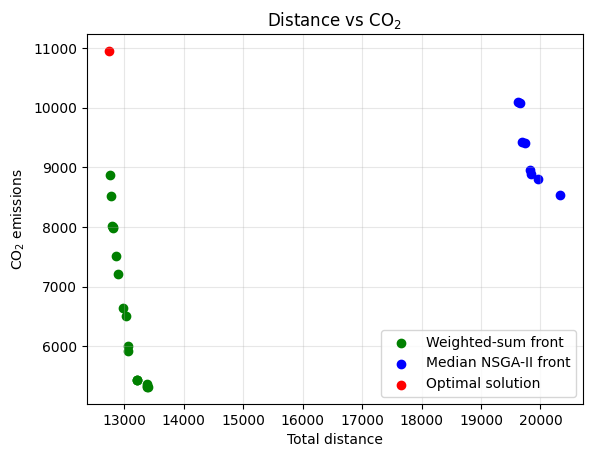

In [15]:
weighted_points = [
(12759, 8864.556466563767, 0.9319397993311037, 0.06806020066889631), 
(12769, 8516.662747928603, 0.9379598662207358, 0.06204013377926422), 
(12796, 8014.382500613516, 0.9048494983277592, 0.0951505016722408), 
(12808, 8002.729358937633, 0.9108695652173913, 0.0891304347826087), 
(12815, 7991.475809704534, 0.9229096989966555, 0.07709030100334449), 
(12865, 7517.635751607366, 0.895819397993311, 0.10418060200668897), 
(12892, 7206.096787897069, 0.8807692307692307, 0.11923076923076924), 
(12981, 6647.480111221971, 0.8777591973244148, 0.12224080267558528), 
(13022, 6504.896763453358, 0.8476588628762542, 0.1523411371237458), 
(13058, 6010.878996227031, 0.8055183946488295, 0.19448160535117054), 
(13071, 5920.449925094986, 0.8235785953177257, 0.17642140468227424), 
(13210, 5440.939158973059, 0.7663879598662207, 0.2336120401337793), 
(13212, 5438.298413746107, 0.5255852842809365, 0.4744147157190635), 
(13217, 5435.818493512536, 0.6760869565217391, 0.32391304347826083), 
(13376, 5362.811929227656, 0.33595317725752505, 0.664046822742475), 
(13385, 5338.1164375097305, 0.1734113712374582, 0.8265886287625418), 
(13389, 5324.173577114994, 0.15836120401337794, 0.8416387959866221), 
(13396, 5319.712177049206, 0.19448160535117054, 0.8055183946488295)]

weighted_points = change_fronts(weighted_points)
optimal_pt = (12747, 10951.48)

plot_fronts(weighted_points, median_front, optimal_pt)
